
# Week 3: Preprocessing and Baseline CNN

## Project
**Automated Casting Defect Detection Using Deep Learning and Computer Vision**

## Week 3 Objective
The aim of Week 3 is to move from Week 2 dataset understanding into the first working modelling pipeline.  
This notebook prepares the image dataset for training, builds a TensorFlow input pipeline, applies data augmentation, calculates class weights and trains a baseline Custom CNN model.

## Team Contributions

| Member | Name | Role | Week 3 Contribution |
|---|---|---|---|
| Member 1 | Sandeep Bommagoni | Data & EDA Lead | Dataset loading, clean manifest creation and train/validation/test split |
| Member 2 | Likith Kumar Devulapalli | Architecture / Xception Lead | Image preprocessing pipeline and data augmentation preview |
| Member 3 | Raghava Krishna Battu | Model Comparison Lead | Custom CNN baseline architecture and training setup |
| Member 4 | Navatej Patel Cheerneni | Evaluation & XAI Lead | Baseline evaluation, confusion matrix, classification report and interpretation |
| Member 5 | Tharun Chinnachinnaiahgari | GitHub / Deployment Lead | File saving, result organisation, Week 3 summary and GitHub evidence |



## 1. Import Libraries

**Contributor:** Tharun Chinnachinnaiahgari  
This section imports libraries required for data preparation, TensorFlow training, visualisation and evaluation.


In [4]:

# Contributor: Tharun Chinnachinnaiahgari
# Task: Import libraries and set random seeds

import os
import json
import random
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")


TensorFlow version: 2.17.0
Libraries imported successfully.



## 2. Configuration and Folder Setup

**Contributor:** Tharun Chinnachinnaiahgari  
This defines dataset paths and output folders. The notebook prefers the unaugmented `casting_512x512` dataset because it is more suitable for controlled preprocessing and augmentation.


In [5]:

# Contributor: Tharun Chinnachinnaiahgari
# Task: Configure dataset paths and output folders

DATASET_ROOT = Path("/kaggle/input/real-life-industrial-dataset-of-casting-product")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15

LABEL_TO_ID = {"ok_front": 0, "def_front": 1}
ID_TO_LABEL = {0: "ok_front", 1: "def_front"}

OUTPUT_DIR = Path("/kaggle/working/week3_baseline_cnn")
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
REPORT_DIR = OUTPUT_DIR / "reports"

for folder in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Output directory:", OUTPUT_DIR)
print("Label mapping:", ID_TO_LABEL)


Dataset root: /kaggle/input/real-life-industrial-dataset-of-casting-product
Output directory: /kaggle/working/week3_baseline_cnn
Label mapping: {0: 'ok_front', 1: 'def_front'}



## 3. Select Dataset Source

**Contributor:** Sandeep Bommagoni  
This section identifies the correct dataset folder containing both `ok_front` and `def_front`.  
The preferred source is the unaugmented 512×512 dataset.


In [6]:

# Contributor: Sandeep Bommagoni
# Task: Discover and select dataset source

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def discover_class_pairs(root: Path):
    pairs = []
    for def_dir in root.rglob("def_front"):
        parent = def_dir.parent
        if (parent / "ok_front").is_dir():
            pairs.append(parent)
    return sorted(set(pairs))

class_pairs = discover_class_pairs(DATASET_ROOT)

if not class_pairs:
    raise FileNotFoundError(f"No valid dataset folder found under {DATASET_ROOT}")

print("Discovered class-folder parents:")
for pair in class_pairs:
    print(" -", pair)

raw_512_pairs = [p for p in class_pairs if "512" in str(p).lower()]

if raw_512_pairs:
    selected_source = raw_512_pairs[0]
else:
    selected_source = class_pairs[0]

print("\nSelected dataset source:", selected_source)


Discovered class-folder parents:
 - /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512
 - /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test
 - /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train

Selected dataset source: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512



## 4. Create Clean Image Manifest

**Contributor:** Sandeep Bommagoni  
This manifest stores image path, label name and numeric label. It is used for preprocessing and model training.


In [7]:

# Contributor: Sandeep Bommagoni
# Task: Create clean image manifest

records = []

for label_name, label_id in LABEL_TO_ID.items():
    class_dir = selected_source / label_name

    for path in sorted(class_dir.iterdir()):
        if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS:
            image = cv2.imread(str(path))
            records.append({
                "path": str(path),
                "filename": path.name,
                "label_name": label_name,
                "label": label_id,
                "readable": image is not None,
                "height": None if image is None else image.shape[0],
                "width": None if image is None else image.shape[1],
            })

manifest = pd.DataFrame(records)

print("Total files found:", len(manifest))
print("Unreadable files:", int((~manifest["readable"]).sum()))

manifest = manifest[manifest["readable"]].reset_index(drop=True)

display(manifest.groupby("label_name").size().reset_index(name="image_count"))
display(manifest.head())

manifest.to_csv(REPORT_DIR / "week3_clean_image_manifest.csv", index=False)


Total files found: 1300
Unreadable files: 0


,label_name,image_count
0,def_front,781
1,ok_front,519


,path,filename,label_name,label,readable,height,width
0,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1018.jpeg,ok_front,0,True,512,512
1,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1021.jpeg,ok_front,0,True,512,512
2,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1028.jpeg,ok_front,0,True,512,512
3,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1074.jpeg,ok_front,0,True,512,512
4,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1082.jpeg,ok_front,0,True,512,512



## 5. Train / Validation / Test Split

**Contributor:** Sandeep Bommagoni  
A stratified split is created so that both classes are represented in training, validation and testing.  
The final model-selection decision should be based on validation results, while the test set should be used only for final evaluation.


In [8]:

# Contributor: Sandeep Bommagoni
# Task: Create stratified train, validation and test splits

train_df, temp_df = train_test_split(
    manifest,
    train_size=TRAIN_FRACTION,
    stratify=manifest["label"],
    random_state=SEED,
)

validation_ratio_from_temp = VALIDATION_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION)

validation_df, test_df = train_test_split(
    temp_df,
    train_size=validation_ratio_from_temp,
    stratify=temp_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_manifest = pd.concat([
    train_df.assign(split="train"),
    validation_df.assign(split="validation"),
    test_df.assign(split="test")
], ignore_index=True)

split_counts = split_manifest.groupby(["split", "label_name"]).size().reset_index(name="images")
display(split_counts)

split_manifest.to_csv(REPORT_DIR / "week3_train_validation_test_manifest.csv", index=False)
split_counts.to_csv(REPORT_DIR / "week3_split_counts.csv", index=False)


,split,label_name,images
0,test,def_front,118
1,test,ok_front,78
2,train,def_front,546
3,train,ok_front,363
4,validation,def_front,117
5,validation,ok_front,78



## 6. TensorFlow Preprocessing Pipeline

**Contributor:** Likith Kumar Devulapalli  
This section creates a `tf.data` pipeline. Images are decoded, resized to 224×224 and batched for CNN training.


In [9]:

# Contributor: Likith Kumar Devulapalli
# Task: Build TensorFlow image preprocessing pipeline

AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)

def make_dataset(dataframe: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = dataframe["path"].astype(str).to_numpy()
    labels = dataframe["label"].astype(np.float32).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=False)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, training=True)
validation_ds = make_dataset(validation_df, training=False)
test_ds = make_dataset(test_df, training=False)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image value range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image value range: 4.243052005767822 to 255.0000457763672



## 7. Data Augmentation Preview

**Contributor:** Likith Kumar Devulapalli  
Data augmentation is applied only during training. This improves model generalisation by showing the CNN realistic variations of the same casting image.


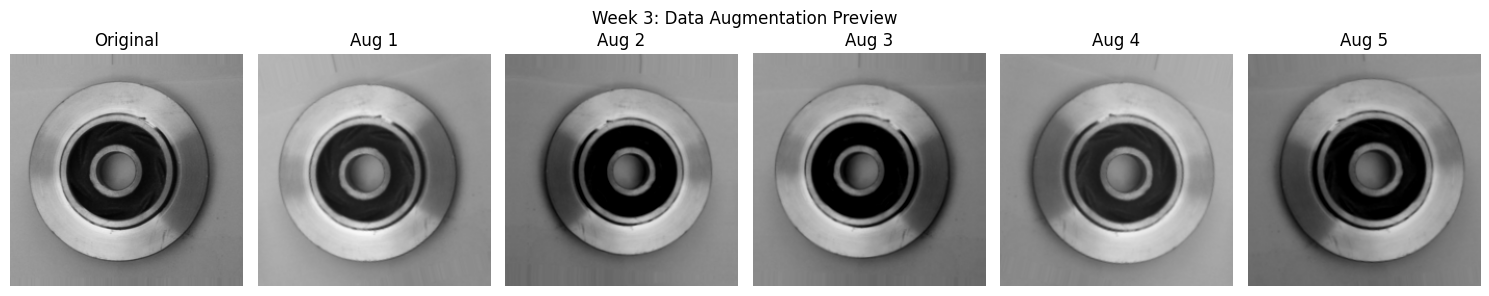

In [10]:

# Contributor: Likith Kumar Devulapalli
# Task: Create and preview data augmentation pipeline

def make_augmentation():
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.04, fill_mode="reflect"),
            layers.RandomZoom(0.08, fill_mode="reflect"),
            layers.RandomContrast(0.10),
            layers.RandomBrightness(0.08, value_range=(0, 255)),
        ],
        name="augmentation",
    )

augmentation = make_augmentation()

for images, labels in train_ds.take(1):
    sample = images[:1]
    sample_label = labels[:1]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(tf.cast(sample[0], tf.uint8))
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 6):
    aug_img = augmentation(sample, training=True)
    axes[i].imshow(tf.cast(tf.clip_by_value(aug_img[0], 0, 255), tf.uint8))
    axes[i].set_title(f"Aug {i}")
    axes[i].axis("off")

plt.suptitle("Week 3: Data Augmentation Preview")
plt.tight_layout()
plt.savefig(PLOT_DIR / "week3_augmentation_preview.png", dpi=160)
plt.show()



## 8. Class Weight Calculation

**Contributor:** Sandeep Bommagoni  
Class weights help reduce the impact of class imbalance during model training.


In [11]:

# Contributor: Sandeep Bommagoni
# Task: Calculate class weights for baseline training

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].to_numpy(),
)

CLASS_WEIGHTS = {
    0: float(class_weight_values[0]),
    1: float(class_weight_values[1]),
}

print("Class weights:", CLASS_WEIGHTS)
with open(REPORT_DIR / "week3_class_weights.json", "w") as f:
    json.dump(CLASS_WEIGHTS, f, indent=4)


Class weights: {0: 1.2520661157024793, 1: 0.8324175824175825}



## 9. Build Baseline Custom CNN

**Contributor:** Raghava Krishna Battu  
A baseline CNN is trained before using advanced transfer-learning models.  
This gives a performance reference point for later comparison with Xception, MobileNetV2 and EfficientNetB0.


In [12]:

# Contributor: Raghava Krishna Battu
# Task: Build Custom CNN baseline model

def build_custom_cnn():
    inputs = keras.Input(shape=IMAGE_SIZE + (3,), name="image")

    x = augmentation(inputs)
    x = layers.Rescaling(1.0 / 255.0, name="rescale")(x)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.35)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="probability_defective")(x)

    model = keras.Model(inputs, outputs, name="Week3_CustomCNN_Baseline")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="defect_precision"),
            keras.metrics.Recall(name="defect_recall"),
            keras.metrics.AUC(name="roc_auc", curve="ROC"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )

    return model

baseline_model = build_custom_cnn()
baseline_model.summary()


Model: "Week3_CustomCNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescale (Rescaling)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ probability_defective (Dense)        │ (None, 1)                   │             2

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)


## 10. Train Baseline CNN

**Contributor:** Raghava Krishna Battu  
This section trains the first baseline model using callbacks for checkpointing, early stopping and learning-rate reduction.


In [13]:

# Contributor: Raghava Krishna Battu
# Task: Train Custom CNN baseline model

EPOCHS = 12

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_DIR / "week3_custom_cnn_best.keras",
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(REPORT_DIR / "week3_custom_cnn_training_log.csv"),
]

start_time = time.time()

history = baseline_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks,
    verbose=1,
)

training_time = time.time() - start_time
print(f"Training time: {training_time/60:.2f} minutes")


Epoch 1/12
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8452 - defect_precision: 0.9354 - defect_recall: 0.7897 - loss: 0.3864 - pr_auc: 0.9438 - roc_auc: 0.9013
Epoch 5: val_pr_auc did not improve from 0.83254

Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.8440 - defect_precision: 0.9352 - defect_recall: 0.7882 - loss: 0.3864 - pr_auc: 0.9438 - roc_auc: 0.9014 - val_accuracy: 0.6000 - val_defect_precision: 0.6000 - val_defect_recall: 1.0000 - val_loss: 2.0187 - val_pr_auc: 0.6681 - val_roc_auc: 0.5953 - learning_rate: 3.0000e-04
Epoch 6/12
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8497 - defect_precision: 0.8867 - defect_recall: 0.8569 - loss: 0.3730 - pr_auc: 0.9490 - roc_auc: 0.9153
Epoch 6: val_pr_auc did not improve from 0.83254
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.8494 - defect_precision: 0.8883 - defect_recall: 0.8546 - loss: 0.3725 - pr_auc: 0.9491 - roc_a


## 11. Plot Training Curves

**Contributor:** Navatej Patel Cheerneni  
Training curves help evaluate whether the model is learning, underfitting or overfitting.


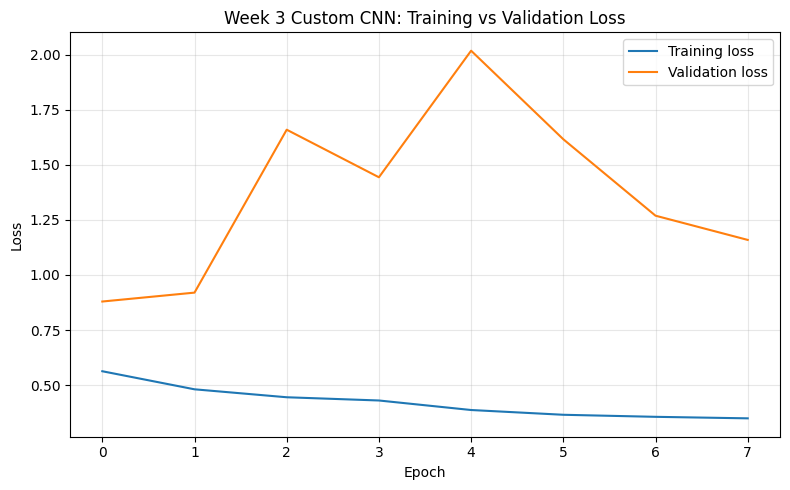

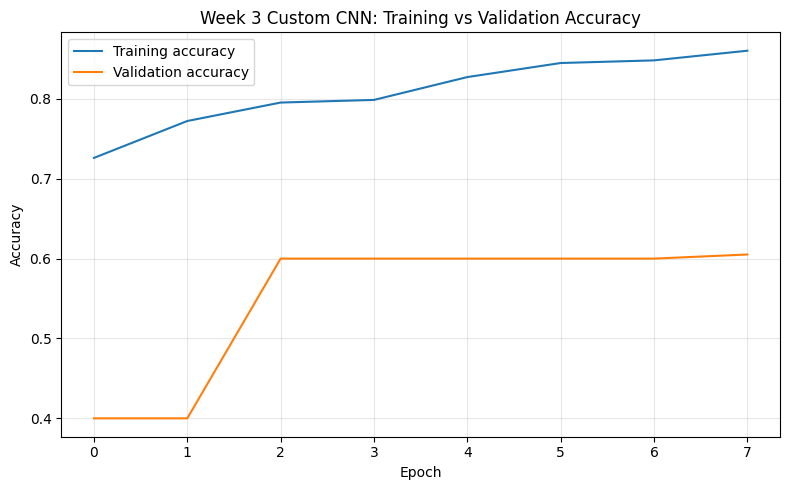

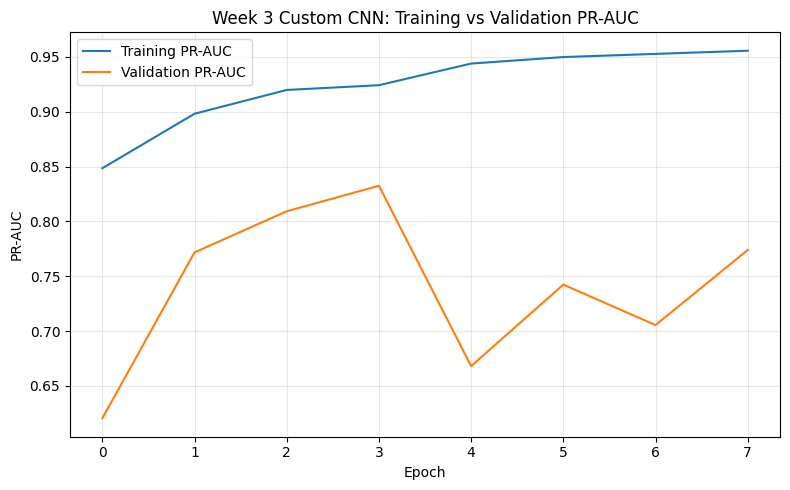

In [14]:

# Contributor: Navatej Patel Cheerneni
# Task: Plot baseline training curves

history_df = pd.DataFrame(history.history)
history_df.to_csv(REPORT_DIR / "week3_custom_cnn_history.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["loss"], label="Training loss")
ax.plot(history_df["val_loss"], label="Validation loss")
ax.set_title("Week 3 Custom CNN: Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "week3_baseline_loss.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["accuracy"], label="Training accuracy")
ax.plot(history_df["val_accuracy"], label="Validation accuracy")
ax.set_title("Week 3 Custom CNN: Training vs Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "week3_baseline_accuracy.png", dpi=160)
plt.show()

if "pr_auc" in history_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_df["pr_auc"], label="Training PR-AUC")
    ax.plot(history_df["val_pr_auc"], label="Validation PR-AUC")
    ax.set_title("Week 3 Custom CNN: Training vs Validation PR-AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "week3_baseline_pr_auc.png", dpi=160)
    plt.show()



## 12. Baseline Validation Evaluation

**Contributor:** Navatej Patel Cheerneni  
The baseline CNN is evaluated on validation data using accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC and confusion matrix.


In [15]:

# Contributor: Navatej Patel Cheerneni
# Task: Evaluate baseline model on validation data

def collect_labels(dataset):
    return np.concatenate([labels.numpy().reshape(-1) for _, labels in dataset]).astype(int)

def collect_probabilities(model, dataset):
    return model.predict(dataset, verbose=0).reshape(-1)

y_val = collect_labels(validation_ds)
val_probabilities = collect_probabilities(baseline_model, validation_ds)
val_predictions = (val_probabilities >= 0.5).astype(int)

baseline_metrics = {
    "threshold": 0.5,
    "accuracy": float(accuracy_score(y_val, val_predictions)),
    "defect_precision": float(precision_score(y_val, val_predictions, pos_label=1, zero_division=0)),
    "defect_recall": float(recall_score(y_val, val_predictions, pos_label=1, zero_division=0)),
    "f1_defect": float(f1_score(y_val, val_predictions, pos_label=1, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_val, val_probabilities)),
    "pr_auc": float(average_precision_score(y_val, val_probabilities)),
    "training_minutes": float(training_time / 60),
}

print("Baseline validation metrics:")
print(json.dumps(baseline_metrics, indent=4))

with open(REPORT_DIR / "week3_baseline_validation_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=4)

report_dict = classification_report(
    y_val,
    val_predictions,
    target_names=["ok_front", "def_front"],
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)
report_df.to_csv(REPORT_DIR / "week3_baseline_classification_report.csv")

cm = confusion_matrix(y_val, val_predictions, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["Actual ok_front", "Actual def_front"], columns=["Pred ok_front", "Pred def_front"])
display(cm_df)
cm_df.to_csv(REPORT_DIR / "week3_baseline_confusion_matrix.csv")


Baseline validation metrics:
{
    "threshold": 0.5,
    "accuracy": 0.6,
    "defect_precision": 0.6,
    "defect_recall": 1.0,
    "f1_defect": 0.7499999999999999,
    "roc_auc": 0.7324128862590401,
    "pr_auc": 0.833435470644744,
    "training_minutes": 0.5677060643831889
}


,precision,recall,f1-score,support
ok_front,0.00,0.0,0.000,78.0
def_front,0.60,1.0,0.750,117.0
accuracy,0.60,0.6,0.600,0.6
macro avg,0.30,0.5,0.375,195.0
weighted avg,0.36,0.6,0.450,195.0


,Pred ok_front,Pred def_front
Actual ok_front,0,78
Actual def_front,0,117


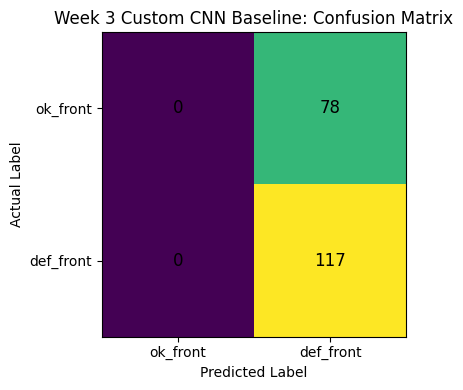

In [16]:

# Contributor: Navatej Patel Cheerneni
# Task: Plot confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_title("Week 3 Custom CNN Baseline: Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["ok_front", "def_front"])
ax.set_yticklabels(["ok_front", "def_front"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig(PLOT_DIR / "week3_baseline_confusion_matrix.png", dpi=160)
plt.show()



## 13. Save Baseline Model and Metadata

**Contributor:** Tharun Chinnachinnaiahgari  
This saves the trained baseline model and metadata for reproducibility.


In [17]:

# Contributor: Tharun Chinnachinnaiahgari
# Task: Save baseline model and metadata

baseline_model.save(MODEL_DIR / "week3_custom_cnn_baseline.keras")

metadata = {
    "week": "Week 3",
    "model_name": "Custom CNN baseline",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "label_mapping": ID_TO_LABEL,
    "class_weights": CLASS_WEIGHTS,
    "validation_metrics": baseline_metrics,
    "training_minutes": training_time / 60,
    "notes": "This is the first baseline CNN model. It will be compared against transfer-learning models in later weeks."
}

with open(REPORT_DIR / "week3_baseline_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved baseline model and metadata.")
print("Model path:", MODEL_DIR / "week3_custom_cnn_baseline.keras")
print("Metadata path:", REPORT_DIR / "week3_baseline_model_metadata.json")


Saved baseline model and metadata.
Model path: /kaggle/working/week3_baseline_cnn/models/week3_custom_cnn_baseline.keras
Metadata path: /kaggle/working/week3_baseline_cnn/reports/week3_baseline_model_metadata.json



## 14. Week 3 Findings

**Contributors:** All Team Members

### What Week 3 Achieved
- Created a clean image manifest.
- Created train/validation/test splits.
- Built a TensorFlow preprocessing pipeline.
- Added training-only data augmentation.
- Calculated class weights.
- Built and trained the first Custom CNN baseline.
- Evaluated the baseline model using validation metrics.
- Saved training curves, confusion matrix, metrics and model metadata.

### Why This Week Matters
Week 3 provides the first measurable model performance. This baseline is important because Week 4 and Week 5 transfer-learning models must be compared against it. Without a baseline, it would be difficult to prove whether advanced architectures such as Xception provide a meaningful improvement.

### Next Week
Week 4 will train the main Xception transfer-learning model and compare its validation performance against the Week 3 baseline CNN.
